# NVDA market regimes and a reinforcement learning trader
## Finding market states without labels, then trading them

- **Author:** Hussein Loubani
- **Dataset:** NVIDIA (NVDA) daily prices from 2010 to today, via yfinance
- **Unsupervised task:** find market regimes in returns and volatility
- **RL task:** learn a long / flat / short policy under transaction costs
- **Caveat:** one stock over one huge bull run is a narrow test. Read every result with that in mind.

---

### Table of contents

1. Imports and setup
2. Problem definition
3. Data acquisition and first audit
4. Train / validation / test split
5. Exploratory data analysis
6. Unsupervised learning: finding market regimes
7. The reinforcement learning environment
8. Tabular agents: Q-learning and SARSA
9. Does the unsupervised layer help? An ablation
10. Final evaluation, walk-forward, and costs
11. Conclusion, limitations, and recommendations

---
## 1. Imports and setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nvda_rl.config import (
    N_REGIMES,
    RANDOM_SEED,
    SPLIT_DATE,
    STATE_BINS,
    STATE_FEATURES,
    VALIDATION_DATE,
)
from nvda_rl.dataset import (
    audit_prices,
    clean_prices,
    download_data,
    extreme_days,
    load_prices,
    split_three_way,
)
from nvda_rl.features import add_features, apply_binner, drop_warmup, fit_binner, regime_matrix
from nvda_rl.modeling import regimes as rg
from nvda_rl.modeling.agents import (
    QLearningAgent,
    SarsaAgent,
    buy_and_hold_policy,
    flat_policy,
    random_policy_factory,
)
from nvda_rl.modeling.environment import TradingEnv
from nvda_rl.modeling.evaluate import (
    action_distribution,
    compare_policies,
    cost_sensitivity,
    equity_curves,
    performance,
    regime_action_map,
    walk_forward,
)
from nvda_rl.plots import (
    apply_global_style,
    plot_action_timeline,
    plot_anomalies,
    plot_equity_curves,
    plot_learning_curves,
    plot_metric_comparison,
    plot_policy_by_regime,
    plot_price_and_volume,
    plot_regime_projection,
    plot_regime_selection,
    plot_regime_timeline,
    plot_return_distribution,
    plot_rolling_sharpe,
    plot_transition_matrix,
    plot_volatility_and_drawdown,
    save_figure,
)

# No global warning filter: silencing everything would also hide the HMM and
# K-means convergence warnings that signal a model which never settled.
apply_global_style()

RAW_DIR = Path.cwd().parent / "data" / "raw"
FIG_DIR = Path.cwd().parent / "reports" / "figures"

---
## 2. Problem definition

| Field | Value |
|---|---|
| **Asset** | NVIDIA (NVDA), daily bars, split and dividend adjusted |
| **Period** | 2010-01-01 to today |
| **Unsupervised goal** | group trading days into a few market regimes I can name |
| **RL goal** | pick a position in {-1 short, 0 flat, +1 long} each day |
| **Split** | chronological: train, then validation for tuning, then a sealed test |

**The business question.** A trader already knows NVDA behaves differently in a calm advance than in a violent drawdown. But "differently" is not something you can trade. The unsupervised half turns that intuition into a label on every day. The RL half asks whether a policy that sees the label decides better than one that does not. That second answer is the actual deliverable, and it has to be measured fairly, which turns out to be the hard part.

**Why RL and not a return forecast.** A model predicting tomorrow's return optimizes accuracy, which is the wrong target. What matters is position sizing under costs, and that is sequential: the cost of being long tomorrow depends on whether I am long today. That dependence makes this an MDP, and it is why the current position sits inside the state.

| Element | Definition |
|---|---|
| **State** | binned market features, optionally the regime label, plus the position held |
| **Action** | the position to hold into the next day |
| **Reward** | $r_t = a_t \cdot \text{next return}_t - \text{cost} \cdot |a_t - a_{t-1}|$ |
| **Transition** | replay of the historical tape; only the position responds to the agent |
| **Discount** | 0.99, so positions are valued over weeks |

That reward is the specification $r_t = a_{t-1}\cdot\text{return}_t - \text{cost}\cdot|a_t - a_{t-1}|$ written from the decision's point of view rather than the settlement's. The position chosen at the close of day *t* is the one that earns day *t+1*'s return. Section 7 explains why that distinction is not pedantry: getting it wrong shifted every result in an earlier version of this notebook.

**Primary metric:** cumulative PnL against buy-and-hold. **Secondary:** annualized return, Sharpe, max drawdown, hit ratio, turnover. Turnover matters more than it looks, because it is what the cost multiplies.

---
## 3. Data acquisition and first audit

### 3.1 Download and load

In [2]:
download_data(RAW_DIR)          # skips the download when the cache exists
prices = load_prices(RAW_DIR)
audit_prices(prices)

  NVDA cached (NVDA.csv)


,NVDA
rows,4166
first_date,2010-01-04
last_date,2026-07-28
duplicate_dates,0
missing_close,0
missing_volume,0
non_positive_close,0
max_gap_days,5
mean_daily_return_%,0.1884
daily_vol_%,2.864


### 3.2 Audit findings

The series is clean. No duplicate dates, no missing closes or volumes, no non-positive prices, and the largest calendar gap is five days, which is a long weekend rather than a hole.

Prices come split and dividend adjusted. NVDA split several times here, and unadjusted closes would show huge fake overnight losses on those dates. A regime model fed that would happily find a "crash" regime that is really a corporate action.

### 3.3 Cleaning, then returns

The order matters and it changed in this version. `load_prices` now returns raw prices only, and `clean_prices` removes duplicate dates and bad closes **before** differencing. Computing returns first would leave the row after a deleted bar holding a return measured against a row that no longer exists. The current NVDA file is clean enough that this changes nothing today, but a cleaning function that only works on already-clean data is not much of a cleaning function.

In [3]:
prices = clean_prices(prices)
print(f"Rows after cleaning: {len(prices):,}")
extreme_days(prices, n=5)

Rows after cleaning: 4,165


,date,close,volume,kind,return_%
0,2016-11-11,2.160570,2175344000,largest gain,29.81
1,2023-05-25,37.902237,1543911000,largest gain,24.37
2,2025-04-09,114.170006,612918300,largest gain,18.72
3,2017-05-10,2.987143,2129096000,largest gain,17.83
4,2020-03-24,6.197947,1101644000,largest gain,17.16
5,2018-11-16,4.067513,1963520000,largest loss,-18.76
6,2020-03-16,4.885130,726972000,largest loss,-18.45
7,2025-01-27,118.243401,818830900,largest loss,-16.97
8,2019-01-28,3.417375,2511528000,largest loss,-13.82
9,2020-03-12,5.380358,816540000,largest loss,-12.24


These are real market history, not data errors, so nothing is trimmed. The biggest moves cluster around earnings and the 2020 and 2022 shocks, which are exactly the days a regime model exists to find.

### 3.4 Feature construction

Every feature at day *t* uses information up to *t*'s close. The environment then pays day *t+1*'s return for a position taken at *t*.

In [4]:
featured = drop_warmup(add_features(prices))
print(f"Rows after dropping the rolling-window warm-up: {len(featured):,}")
print(f"Date range: {featured['date'].min().date()} to {featured['date'].max().date()}")
print(f"State features: {STATE_FEATURES}")
featured[["date", "close", *STATE_FEATURES]].tail(3)

Rows after dropping the rolling-window warm-up: 3,914
Date range: 2011-01-03 to 2026-07-28
State features: ['return', 'volatility_21', 'momentum_21', 'dist_252d_high', 'volume_zscore']


,date,close,return,volatility_21,momentum_21,dist_252d_high,volume_zscore
3911,2026-07-24,206.839996,-0.009197,0.351890,0.039397,-0.121570,-1.229214
3912,2026-07-27,196.509995,-0.049942,0.392871,0.003934,-0.165441,-0.393070
3913,2026-07-28,197.970001,0.007430,0.388762,0.028255,-0.159240,-2.034928


The first trading year cannot produce a full feature row, because distance from the 252-day high needs a year of history. Those rows are dropped, not filled.

---
## 4. Train / validation / test split

Three windows, not two. Hyperparameters are chosen on validation and the test window is opened once, at the end.

In [5]:
train, valid, test = split_three_way(featured)
for name, w in [("train", train), ("validation", valid), ("test", test)]:
    print(f"{name:11s} {len(w):5,} days   {w['date'].min().date()} to {w['date'].max().date()}")
print(f"\nvalidation starts {VALIDATION_DATE}, test starts {SPLIT_DATE}")

train       2,012 days   2011-01-03 to 2018-12-31
validation    505 days   2019-01-02 to 2020-12-31
test        1,397 days   2021-01-04 to 2026-07-28

validation starts 2019-01-01, test starts 2021-01-01


**Why three windows.** The earlier version chose the learning rate after watching training behaviour and then reported a test number, which quietly makes that test number partly in-sample. Every tuning decision below, the learning rate, the episode count, the bin count, and the number of regimes, is made against validation. The test window is untouched until Section 10.

**Why chronological.** Shuffling would let the agent train on tomorrow and be tested on yesterday. The subtler version is fitting the regime model on everything and splitting afterwards, so a test-day label carries information from days the agent never traded. Every unsupervised model below is fitted on `train` alone. `tests/test_leakage.py` proves it by running the whole fitting workflow against two wildly different test sets and asserting the bin edges, scaler parameters, and centroids come out identical.

---
## 5. Exploratory data analysis

### 5.1 Price and volume

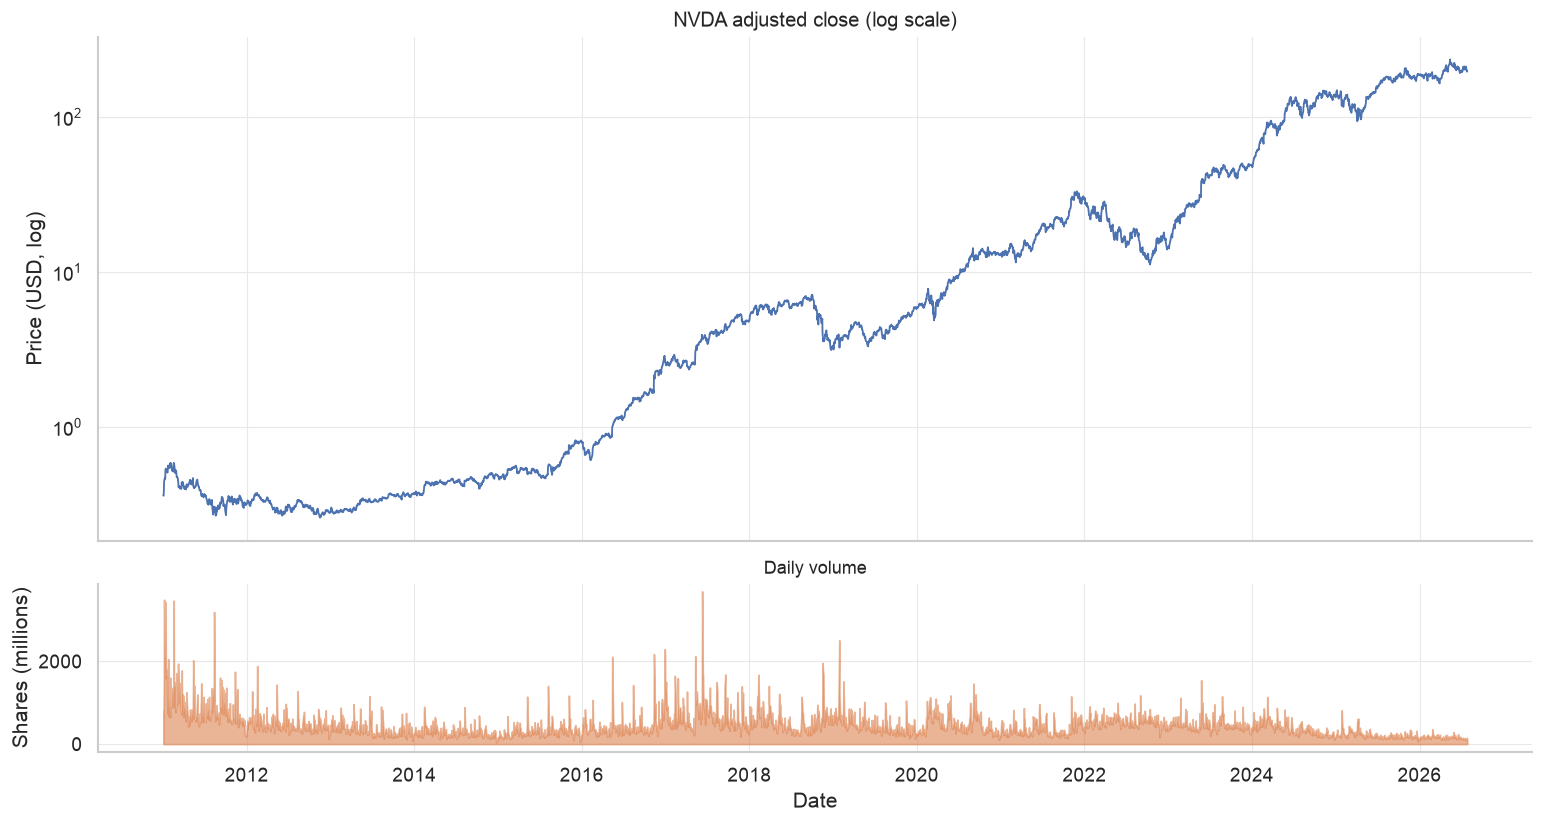

In [6]:
fig = plot_price_and_volume(featured)
plt.show()
save_figure(fig, "price_and_volume", FIG_DIR / "eda")

The log axis is necessary. NVDA compounded more than a hundredfold here, and on a linear scale the whole first decade flattens into a line at the bottom.

### 5.2 Return distribution

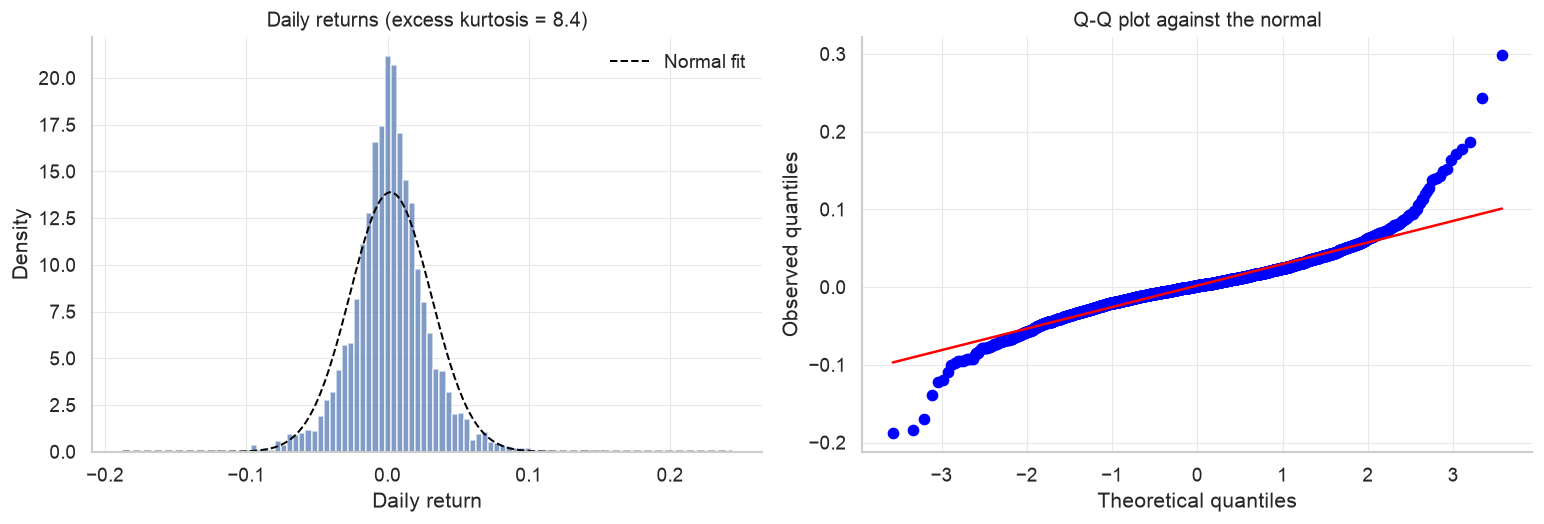

In [7]:
fig = plot_return_distribution(featured)
plt.show()
save_figure(fig, "return_distribution", FIG_DIR / "eda")

A sharp peak near zero and tails much heavier than a normal allows. Any method assuming Gaussian returns is mis-specified here, and it is why the regime features lean on volatility: in a fat-tailed series, how much the market moves is more stable and more learnable than which way it went.

### 5.3 Volatility and drawdown

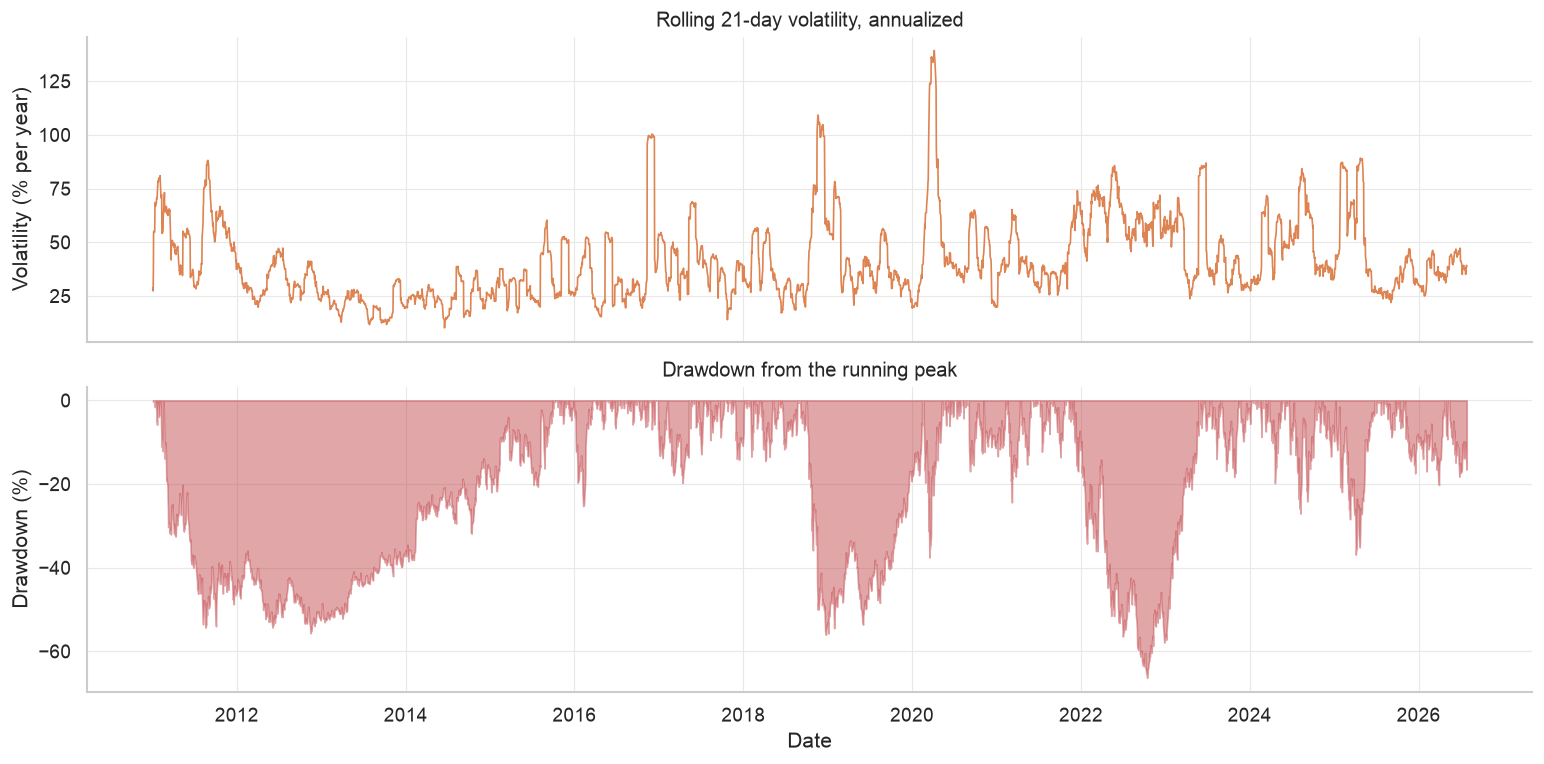

In [8]:
fig = plot_volatility_and_drawdown(featured)
plt.show()
save_figure(fig, "volatility_and_drawdown", FIG_DIR / "eda")

Volatility clusters: quiet stretches follow quiet ones, violent ones follow violent ones. That persistence is what makes a regime label worth having at all. If volatility were independent day to day, yesterday's regime would tell you nothing about today.

The drawdown panel is the counterweight to the price chart. Even this stock spent long stretches far below its high, including a fall of about two thirds in 2022.

---
## 6. Unsupervised learning: finding market regimes

Clustering gives the discrete regime label that goes into the agent's state; dimensionality reduction is there to check the structure is real rather than K-means being forced onto a shapeless cloud.

### 6.1 How many regimes?

Chosen from diagnostics on the training window, not assumed.

In [9]:
x_train, x_valid, x_test = (regime_matrix(w) for w in (train, valid, test))
selection = rg.select_n_regimes(x_train)
selection

,inertia,silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,7804.2,0.3041,1.4586,581.0
3,6298.0,0.3486,1.2776,600.0
4,5712.5,0.3089,1.3251,509.4
5,5177.8,0.2457,1.5084,473.1
6,4678.5,0.2797,1.2680,461.5
7,4214.9,0.2530,1.2393,463.4
8,3913.2,0.1986,1.2472,449.7


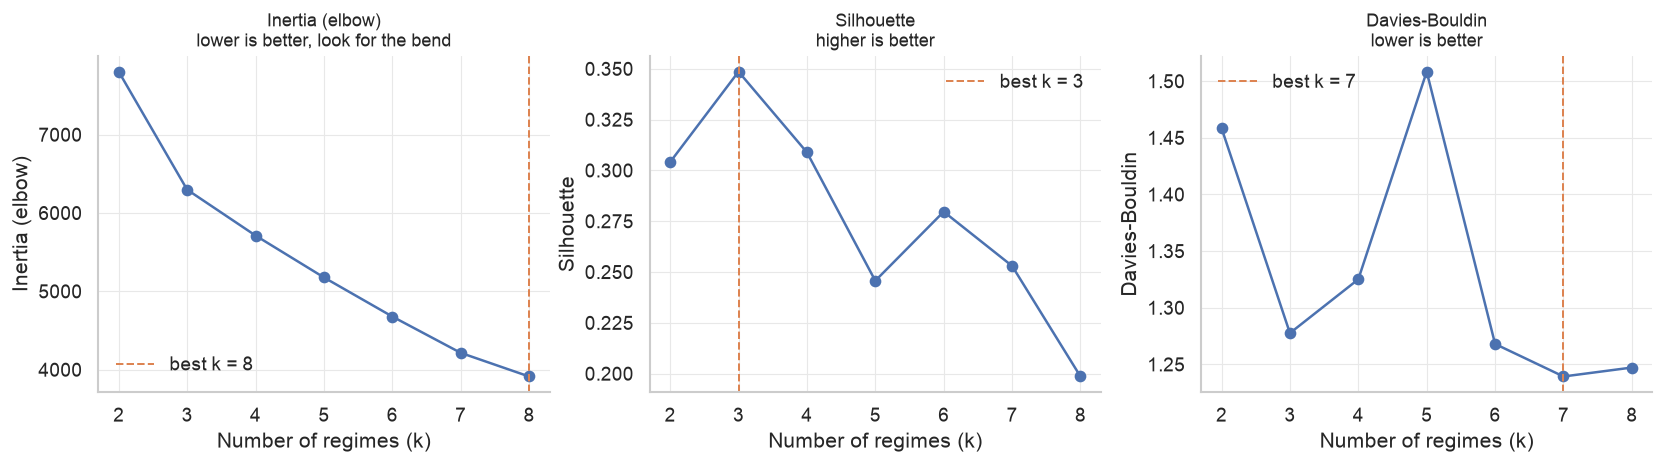

In [10]:
fig = plot_regime_selection(selection)
plt.show()
save_figure(fig, "regime_selection", FIG_DIR / "regimes")

Inertia falls monotonically and only hints at a bend. Silhouette and Calinski-Harabasz both point at a small number of states; Davies-Bouldin can prefer a larger one. Three is chosen because two criteria support it and because three states stay learnable for a tabular agent and describable in a sentence. Section 9 tests that choice where it matters, by measuring whether the resulting labels help the agent at all.

### 6.2 The regimes, fitted on training data only

In [11]:
kmeans_model = rg.fit_kmeans_regimes(x_train, train["return"].to_numpy(), N_REGIMES)
for window, x in [(train, x_train), (valid, x_valid), (test, x_test)]:
    window["regime"] = rg.assign_regimes(kmeans_model, x)

print("Cluster quality on training data:", rg.cluster_quality(x_train, train["regime"].to_numpy()))
rg.regime_profile(train, "regime")

Cluster quality on training data: {'silhouette': 0.3486, 'davies_bouldin': 1.2776, 'n_clusters': 3}


,days,mean_return_bps,ann_return_pct,ann_vol_pct,hit_ratio,mean_momentum,mean_dist_high,share_%
regime,,,,,,,,
0,174,216.0,544.3,72.4,0.718,0.2473,-0.0335,8.6
1,1372,14.9,37.6,25.5,0.531,0.0392,-0.0629,68.2
2,466,-62.9,-158.5,50.9,0.393,-0.0703,-0.3385,23.2


Labels are reordered so regime 0 always has the highest mean return, otherwise the same regime changes identity between runs and every sentence written about "regime 1" rots.

The profile names the three states: a violent melt-up, a calm advance holding most of the days, and a drawdown far below the yearly high.

**But this table is partly circular, and that matters.** Current return is one of the clustering inputs and the labels are then sorted by mean return, so discovering a high-return regime and a low-return regime afterwards is close to guaranteed. It describes the states; it does not show they are useful.

### 6.3 The honest test: what happens *after* the regime is observed

Forward returns, forward volatility, and forward drawdown were never shown to the clustering. If the regimes carry information a trading decision could use, it has to appear here.

In [12]:
rg.forward_regime_profile(train, "regime")

,days,fwd_1d_return_bps,fwd_1d_hit_ratio,fwd_5d_return_bps,fwd_5d_hit_ratio,fwd_21d_vol_%,fwd_21d_drawdown_%
regime,,,,,,,
0,174,59.61,0.59,203.47,0.69,40.94,-4.76
1,1372,13.66,0.52,80.12,0.55,31.88,-4.35
2,466,-1.37,0.48,-18.19,0.50,45.16,-8.46


This is the result that justifies the regimes, and it is genuinely informative.

The day *after* a regime-0 observation returns about +60 basis points on average with a 0.59 hit ratio, and the following five days add roughly +203 bps with a 0.69 hit ratio. Regime 2 is the mirror image: roughly flat to slightly negative the next day, negative over five days, and a 0.48 hit ratio. Forward volatility separates the states too, and forward drawdown almost doubles between the calm regime and the stressed one, about -4.3% against -8.5% over the following month.

So the labels are not merely redescribing today. They carry real information about the near future, particularly about **risk**: knowing the regime tells you more about how much the market is about to move, and how far it might fall, than about which way it will go. Hold onto that, because it explains what happens in Section 9.

### 6.4 Are three regimes stable?

A silhouette score says the clusters are geometrically tidy. It says nothing about whether they would survive a slightly different sample, and a label that moves under reseeding is a poor thing to condition a policy on.

In [13]:
print("Reseeded K-means, agreement with the reference labelling:")
display(rg.regime_stability(x_train, train["return"].to_numpy()))
print("Bootstrap resamples, the harder test:")
display(rg.bootstrap_stability(x_train, train["return"].to_numpy()))

Reseeded K-means, agreement with the reference labelling:


,seeds,mean_ARI,min_ARI,std_ARI,share_above_0.9
0,20,1.0,1.0,0.0,1.0


Bootstrap resamples, the harder test:


,bootstraps,mean_ARI,min_ARI,std_ARI
0,20,0.9156,0.8406,0.0465


Reseeding gives an adjusted Rand index of 1.00 across every seed: the initialisation never changes the answer. Bootstrap resampling is the harder test, since it perturbs the data rather than just the starting point, and agreement stays around 0.91 with a worst case near 0.84. Days move between regimes at the boundaries, which is expected, but the partition itself holds.

That is enough to treat the labels as a stable state variable.

### 6.5 Regime timeline

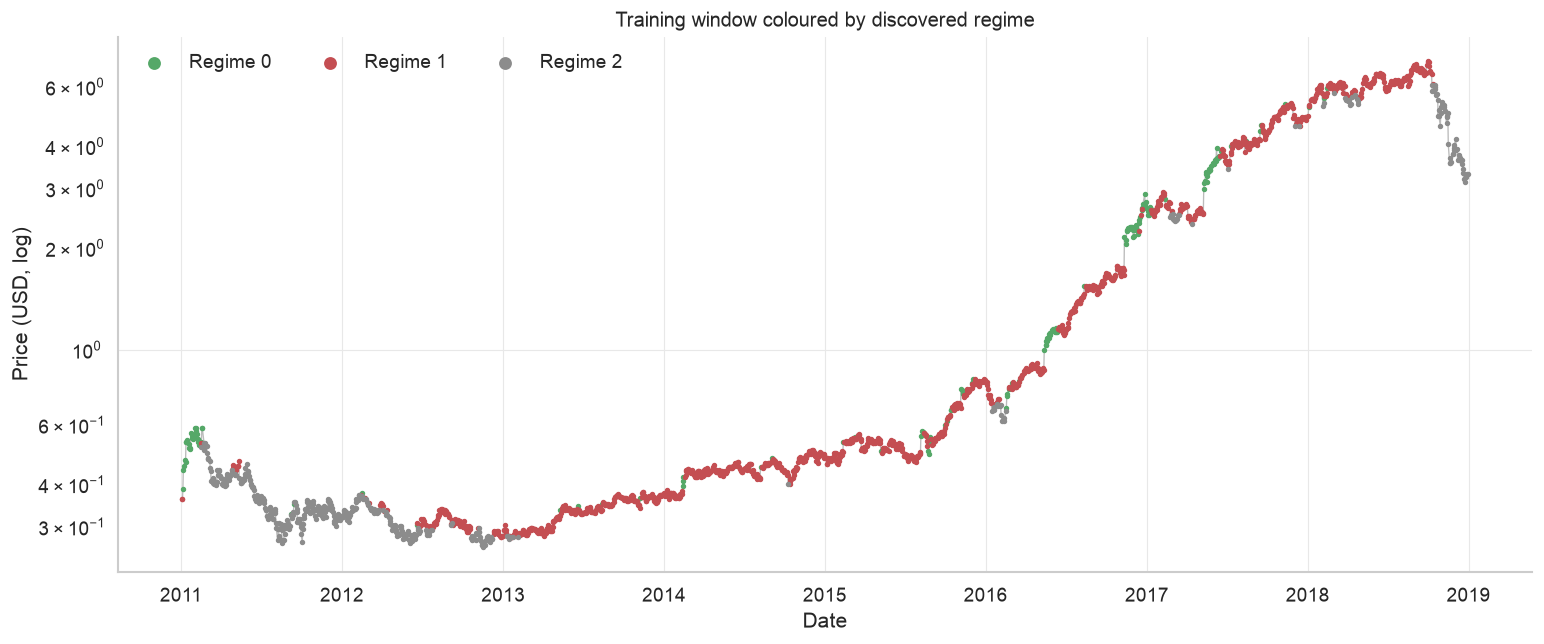

In [14]:
fig = plot_regime_timeline(train, "regime", "Training window coloured by discovered regime")
plt.show()
save_figure(fig, "regime_timeline_train", FIG_DIR / "regimes")

The colours line up with the visible declines and the steep advances, which is what makes the model falsifiable rather than merely plausible.

### 6.6 Persistence

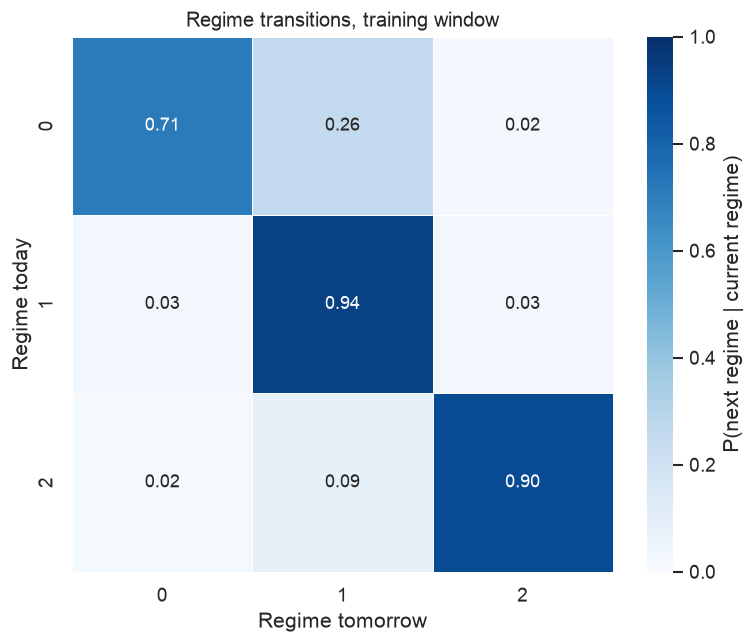

to_regime,0,1,2
from_regime,,,
0,0.713,0.264,0.023
1,0.031,0.937,0.033
2,0.017,0.086,0.897


In [15]:
transitions = rg.transition_matrix(train["regime"].to_numpy())
fig = plot_transition_matrix(transitions, "Regime transitions, training window")
plt.show()
save_figure(fig, "transition_matrix", FIG_DIR / "regimes")
transitions

### 6.7 Seeing the structure: PCA and UMAP

Two projections for two jobs. PCA is linear and its components read as weighted combinations of the original features, so it says *what* separates the regimes. UMAP preserves local neighbourhoods and is better at showing whether the groups are genuinely distinct. Both are fitted on training data only.

In [16]:
pca_pipe = rg.fit_pca(x_train)
rg.pca_loadings(pca_pipe, list(x_train.columns))

,PC1,PC2
return,0.358,0.261
volatility_21,-0.226,0.691
momentum_21,0.605,0.187
dist_252d_high,0.654,-0.228
volume_zscore,0.163,0.606
explained_variance_%,33.900,28.300


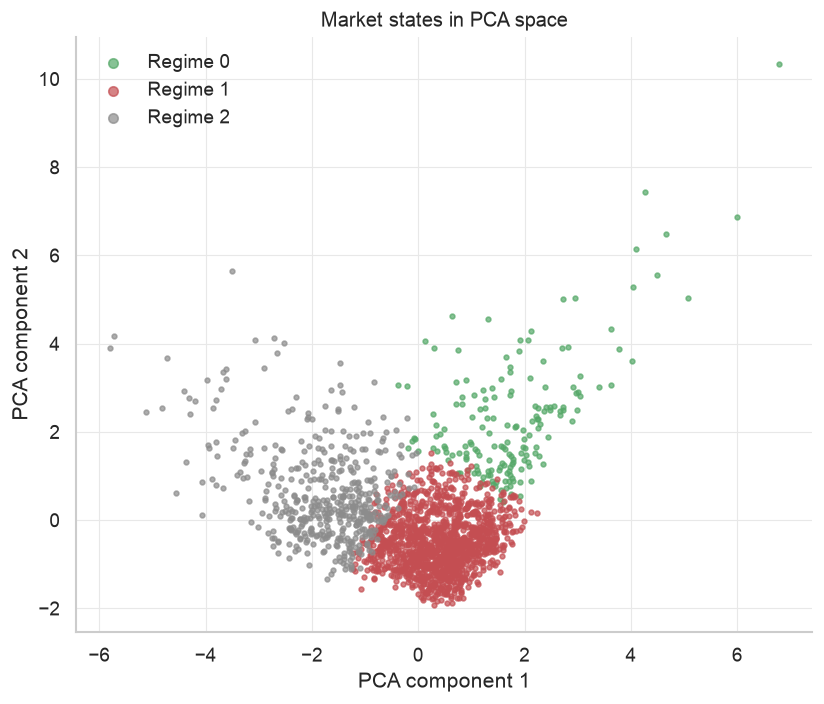

In [17]:
fig = plot_regime_projection(pca_pipe.transform(x_train),
                             train["regime"].to_numpy(), "PCA")
plt.show()
save_figure(fig, "regimes_pca", FIG_DIR / "regimes")

/Users/hussein-loubani/Turing College/Module 3/Sprint 4/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/hussein-loubani/Turing College/Module 3/Sprint 4/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


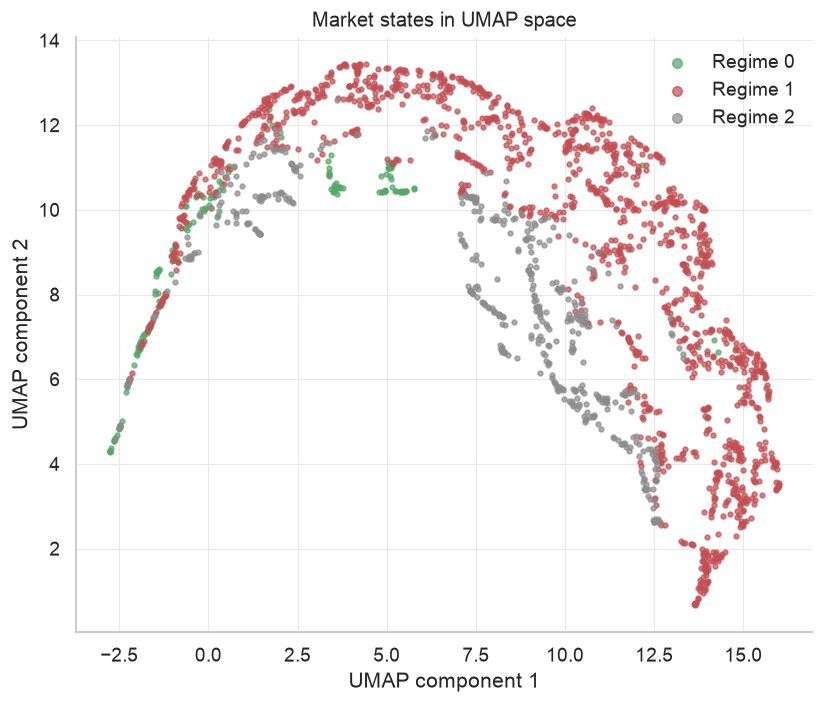

In [18]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=RANDOM_SEED)
fig = plot_regime_projection(reducer.fit_transform(x_train),
                             train["regime"].to_numpy(), "UMAP")
plt.show()
save_figure(fig, "regimes_umap", FIG_DIR / "regimes")

The loadings name the axes: the first component is dominated by volatility and distance from the high moving together, which is the market-stress axis, and the second separates momentum and recent return, the direction axis. That ordering is itself a result, because it says the largest source of variation across market days is how stressed the market is rather than which way it went.

The UMAP view shows the regimes occupying coherent neighbourhoods with genuine overlap at the boundaries, which is honest: days near a boundary really are ambiguous. What matters for a policy is that the centres are distinct.

The diagonal carries the argument: regimes come in runs lasting weeks rather than flickering day to day, which is what makes yesterday's label informative about today.

### 6.7 Alternative clusterings and a sequence model

In [19]:
dbscan_labels, dbscan_info = rg.fit_dbscan(x_train)
agglo_labels = rg.fit_agglomerative(x_train)
print("DBSCAN:", dbscan_info)
print("DBSCAN quality      :", rg.cluster_quality(x_train, dbscan_labels))
print("Agglomerative (Ward):", rg.cluster_quality(x_train, agglo_labels))
print("K-means             :", rg.cluster_quality(x_train, train["regime"].to_numpy()))

DBSCAN: {'n_clusters': 1, 'n_noise': 380, 'noise_share_%': np.float64(18.89)}
DBSCAN quality      : {'silhouette': nan, 'davies_bouldin': nan, 'n_clusters': 0}
Agglomerative (Ward): {'silhouette': 0.3516, 'davies_bouldin': 1.6465, 'n_clusters': 3}
K-means             : {'silhouette': 0.3486, 'davies_bouldin': 1.2776, 'n_clusters': 3}


In [20]:
hmm_model = rg.fit_hmm_regimes(x_train, train["return"].to_numpy(), N_REGIMES)
train["regime_hmm"] = rg.assign_hmm_regimes(hmm_model, x_train)
km_diag = np.diag(rg.transition_matrix(train["regime"].to_numpy()).to_numpy()).mean()
hmm_diag = np.diag(rg.transition_matrix(train["regime_hmm"].to_numpy()).to_numpy()).mean()
print(f"HMM converged: {hmm_model['converged']}")
print(f"Mean persistence: K-means {km_diag:.3f}   HMM {hmm_diag:.3f}")
print("HMM quality:", rg.cluster_quality(x_train, train["regime_hmm"].to_numpy()))

HMM converged: True
Mean persistence: K-means 0.849   HMM 0.960
HMM quality: {'silhouette': 0.2032, 'davies_bouldin': 2.02, 'n_clusters': 3}


Ward linkage finds a comparable three-way split. DBSCAN does not, because market-state space is a continuum without density gaps rather than a set of islands, and it cannot label unseen days anyway, so it stays a diagnostic.

The HMM does what it promises: its regimes persist far longer, because the transition prior holds a day in its current state on its neighbours' evidence. It pays for that in compactness, and its internal scores are worse. I keep K-means as the agent's state feature for a practical reason: `predict` on a frozen K-means pipeline is a per-day lookup, while an HMM decodes a whole sequence, so a test-day label would depend on the days around it. Keeping the assignment strictly per-day makes the no-look-ahead guarantee easy to state and easy to test.

### 6.8 Anomaly detection

Anomalous share, train: 2.2%
Anomalous share, test : 1.7%


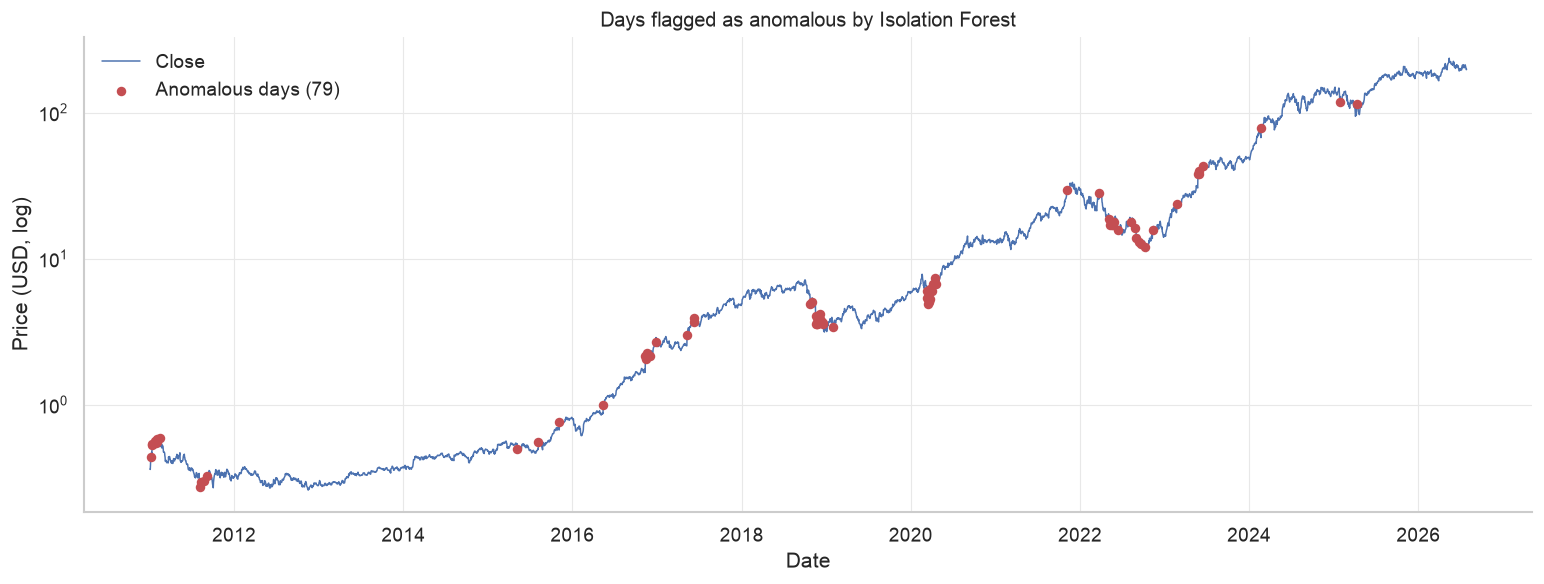

In [21]:
x_all = regime_matrix(featured)
anomalies = rg.detect_anomalies(x_train, x_all)
featured["anomaly_iso"] = anomalies["isolation_forest"]
in_test = featured["date"] >= pd.Timestamp(SPLIT_DATE)
print(f"Anomalous share, train: {(featured.loc[~in_test, 'anomaly_iso'] == -1).mean():.1%}")
print(f"Anomalous share, test : {(featured.loc[in_test, 'anomaly_iso'] == -1).mean():.1%}")
fig = plot_anomalies(featured, featured["anomaly_iso"].to_numpy())
plt.show()
save_figure(fig, "anomalies", FIG_DIR / "regimes")

The detector was fitted on training days with a 2% contamination target, so the training rate is true by construction and the test rate is the measurement. It comes out close to that level rather than far above it, which says the test window is not systematically stranger than what the agent learned from, so the backtest is evaluation rather than extrapolation.

### 6.9 Unsupervised findings

- Three regimes, supported by silhouette and Calinski-Harabasz and chosen for learnability over the alternatives.
- The states are nameable: a violent melt-up, a calm advance, and a drawdown far below the yearly high.
- They hold up on quantities the clustering never saw: forward one-day and five-day returns, forward volatility, and forward drawdown all separate cleanly across regimes.
- They are stable, with a reseeded ARI of 1.00 and a bootstrap ARI around 0.91.
- They persist, so yesterday's label says something about today.
- What they predict best is **risk**, not direction. Forward drawdown roughly doubles between the calm and stressed states while forward direction separates much more weakly.

---
## 7. The reinforcement learning environment

### 7.1 The reward, and a timing bug worth documenting

$$r_t = a_t \cdot \text{next return}_t - \text{cost} \cdot |a_t - a_{t-1}|$$

The position chosen at the close of day *t* earns day *t+1*'s return, and the cost is charged when the position changes.

An earlier version of this notebook got that wrong, and it is worth showing rather than quietly fixing. `next_return` already shifts the return forward by one day. The environment then multiplied it by the position held *before* the current action, which shifts it again. The net effect was that a position decided on day *t* earned the return of day *t+2*: the agent traded on a one-day lag throughout, and every reported number was built on it.

The failure was invisible to the old tests because they all shared the same convention, so they passed while the timeline was wrong. The fix was a test written with named weekdays and one hand-computed number:

```python
# Monday close: the agent goes long. Tuesday: the market rises 10%.
# Entry cost is 10 bps. The Monday step must pay exactly 1 * 0.10 - 0.001.
assert monday_reward == pytest.approx(0.099)
```

That test lives in `tests/modeling/test_environment.py` and it fails loudly if the timeline ever shifts again.

### 7.2 A standard interface

The environment now implements the Gymnasium `Env` contract: `reset` returns `(observation, info)`, `step` returns the five-tuple with `terminated` and `truncated`, and the action and observation spaces are declared. That replaces a set of project-local conventions with an interface other RL tooling already understands.

In [22]:
import subprocess

result = subprocess.run(["uv", "run", "pytest", "-q", "--no-header"],
                        cwd=Path.cwd().parent, capture_output=True, text=True)
print(result.stdout.strip().splitlines()[-1])

83 passed in 1.87s


The suite now mirrors the package: `test_dataset`, `test_features`, `test_plots`, `test_leakage`, and a `modeling/` folder with `test_agents`, `test_environment`, `test_evaluate`, and `test_regimes`, plus `test_pipeline` for the end-to-end checks. The leakage tests were also rewritten. The old one fitted the binner twice on the same frame, which only proved the code was deterministic; the new one runs the whole fitting workflow against two very different test sets and asserts the bin edges, scaler parameters, centroids, and label ordering come out identical.

### 7.3 Discretizing the state, fairly

Two changes here, both of which affect the ablation in Section 9.

The discretization now uses sklearn's `KBinsDiscretizer` rather than hand-rolled quantiles and `np.digitize`. Same fit-on-train contract, one tested component, and consistent with the rest of the pipeline.

More importantly, **the market-only state now uses the same columns the regime model clusters on.** Previously the baseline saw three binned features while the regime was built from five, so the regime label smuggled in two extra inputs and the comparison was rigged in its favour before a single episode ran.

In [23]:
binner = fit_binner(train, STATE_FEATURES, n_bins=STATE_BINS)
train, valid, test = (apply_binner(w, binner) for w in (train, valid, test))

MARKET_STATE = [f"{c}_bin" for c in STATE_FEATURES]
REGIME_STATE = [*MARKET_STATE, "regime"]
print("Market-only state :", MARKET_STATE)
print("Regime-augmented  :", REGIME_STATE)
print(f"\nReachable: market only {STATE_BINS**len(STATE_FEATURES)} x 3 positions "
      f"= {STATE_BINS**len(STATE_FEATURES)*3}")
print(f"           with regime  x{N_REGIMES} = {STATE_BINS**len(STATE_FEATURES)*N_REGIMES*3}")

Market-only state : ['return_bin', 'volatility_21_bin', 'momentum_21_bin', 'dist_252d_high_bin', 'volume_zscore_bin']
Regime-augmented  : ['return_bin', 'volatility_21_bin', 'momentum_21_bin', 'dist_252d_high_bin', 'volume_zscore_bin', 'regime']

Reachable: market only 32 x 3 positions = 96
           with regime  x3 = 288


Adding the regime triples the state space. That is the cost side of the ablation, and with a fixed number of training days more states means fewer visits each and a noisier table.

---
## 8. Tabular agents: Q-learning and SARSA

Tabular by choice. The state space is small and discrete, and the learned policy can be read directly and argued with, which a neural policy cannot.

**Q-learning is off-policy:** its update bootstraps from the best available next action. **SARSA is on-policy:** it bootstraps from the action actually taken, so it prices in the cost of its own exploration and tends to settle somewhere tamer.

### 8.1 Choosing the learning rate on validation

The first configuration used the textbook `alpha = 0.1` and produced a degenerate result: the agent never traded. Daily rewards are roughly 0.2% with a 3% standard deviation, so the target of every update is mostly noise, and at a high learning rate the table chases that noise instead of averaging it. Rather than pick a replacement by looking at the test set, the candidates are scored on the **validation** window.

In [24]:
rows = []
for alpha in (0.001, 0.005, 0.02, 0.1):
    agent = QLearningAgent(alpha=alpha)
    agent.train(TradingEnv(train, MARKET_STATE), n_episodes=300)
    stats = performance(TradingEnv(valid, MARKET_STATE).run_policy(agent.greedy_policy()))
    rows.append({"alpha": alpha, "validation_pnl_%": stats["cumulative_pnl_%"],
                 "sharpe": stats["sharpe"], "turnover": stats["turnover_per_year"],
                 "days_in_market_%": stats["days_in_market_%"]})
pd.DataFrame(rows).set_index("alpha")

,validation_pnl_%,sharpe,turnover,days_in_market_%
alpha,,,,
0.001,240.98,1.49,111.3,95.8
0.005,225.81,1.50,133.2,89.3
0.020,81.98,0.92,149.2,78.0
0.100,-5.64,0.02,93.8,23.6


The validation window picks the rate, and the test set stays sealed. A low rate lets the table average many noisy targets, which is what a value estimate is supposed to be.

### 8.2 Training both agents on both state definitions

In [25]:
agents, curves = {}, {}
for label, cols in [("market only", MARKET_STATE), ("market + regime", REGIME_STATE)]:
    env = TradingEnv(train, cols)
    for AgentClass, name in ((QLearningAgent, "Q-learning"), (SarsaAgent, "SARSA")):
        agent = AgentClass()
        curves[f"{name} [{label}]"] = agent.train(env, n_episodes=600)
        agents[f"{name} [{label}]"] = agent
        print(f"{name} [{label}]: {len(agent.q)} states visited")

Q-learning [market only]: 96 states visited


SARSA [market only]: 96 states visited


Q-learning [market + regime]: 183 states visited


SARSA [market + regime]: 183 states visited


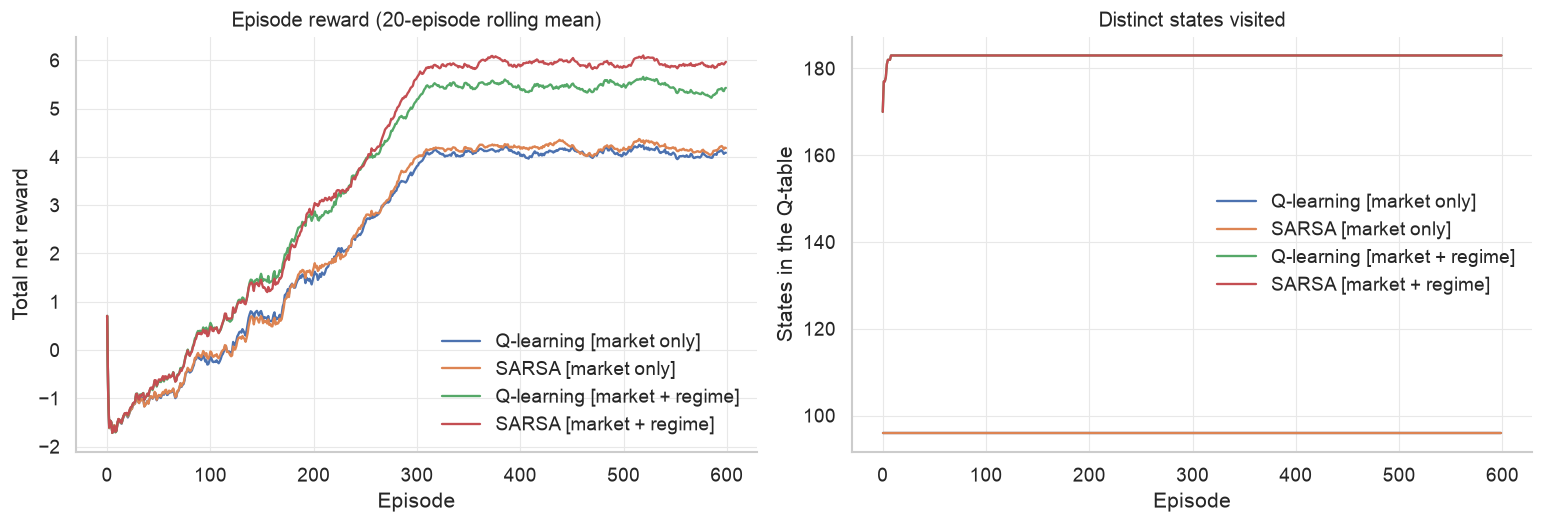

In [26]:
fig = plot_learning_curves(curves)
plt.show()
save_figure(fig, "learning_curves", FIG_DIR / "rl")

Both algorithms improve as epsilon decays and then flatten. State coverage saturates early, so the tables are not still filling in when training stops. The regime-augmented agents visit roughly twice as many states, which is the dilution cost made visible.

---
## 9. Does the unsupervised layer help? An ablation

This is the question the brief asks, and it only has a defensible answer if the two arms differ in exactly one respect. They now do: identical algorithms, hyperparameters, seeds, training data, evaluation window, **and identical underlying features**. The only difference is whether the cluster label is appended.

In [27]:
ledgers = {
    "Buy and hold": TradingEnv(test, MARKET_STATE).run_policy(buy_and_hold_policy),
    "Flat": TradingEnv(test, MARKET_STATE).run_policy(flat_policy),
    "Random": TradingEnv(test, MARKET_STATE).run_policy(random_policy_factory()),
}
for label, cols in [("market only", MARKET_STATE), ("market + regime", REGIME_STATE)]:
    for name in ("Q-learning", "SARSA"):
        key = f"{name} [{label}]"
        ledgers[key] = TradingEnv(test, cols).run_policy(agents[key].greedy_policy())

summary = compare_policies(ledgers)
summary

,cumulative_pnl_%,total_growth_x,ann_return_%,ann_vol_%,sharpe,max_drawdown_%,hit_ratio,days_in_market_%,turnover_per_year,cost_drag_%,days
policy,,,,,,,,,,,
Buy and hold,1414.27,15.143,63.32,50.98,1.22,-66.34,0.534,100.0,0.2,0.1,1396
Q-learning [market only],904.22,10.042,51.65,49.35,1.09,-64.05,0.524,93.2,123.3,68.3,1396
SARSA [market only],623.70,7.237,42.94,46.90,0.99,-60.00,0.522,83.3,139.5,77.3,1396
Q-learning [market + regime],348.04,4.480,31.09,50.64,0.79,-79.83,0.524,98.0,84.7,46.9,1396
Random,95.52,1.955,12.87,42.61,0.49,-49.19,0.506,66.5,221.3,122.6,1396
SARSA [market + regime],25.98,1.260,4.26,46.92,0.32,-68.84,0.515,88.1,79.6,44.1,1396
Flat,0.00,1.000,0.00,0.00,NaN,0.00,NaN,0.0,0.0,0.0,1396


**The regime label makes the agent worse, and the honest answer is that it does not earn its place in the state.**

| Agent | Market only | Market + regime |
|---|---|---|
| Q-learning | +904% | +348% |
| SARSA | +624% | +26% |

Both algorithms lose ground, and SARSA collapses. This is the opposite of what an earlier version of this notebook reported, and the reversal came from two fixes rather than from new data. The timing bug in Section 7.1 was inflating the regime arm, and the baseline was being starved of two features that the regime label quietly carried. Correct the timing, feed both arms the same inputs, and the advantage disappears.

**Why the two results can both be true.** Section 6.3 showed the regimes really do carry forward information, mostly about risk. But a tabular agent cannot use "risk is elevated" unless it can also learn what to do about it, and appending the label triples the state space from 96 to 288 reachable states while the training window stays the same length. Each state gets a third of the visits and the table gets noisier. The information the label adds is worth less than the estimation error it costs.

That is a real and reportable finding: **an informative feature is not automatically a useful state variable.** For a tabular method the state-space budget is the binding constraint, and a function approximator that can share statistical strength across similar states would be the way to use the regimes rather than a bigger lookup table.

### 9.1 How behaviour differs by regime

In [28]:
display(action_distribution(ledgers))
regime_map = regime_action_map(ledgers["Q-learning [market + regime]"], test["regime"])
regime_map

,action_-1_%,action_0_%,action_1_%
Buy and hold,0.0,0.0,100.0
Flat,0.0,100.0,0.0
Random,32.1,33.5,34.5
Q-learning [market only],14.8,6.8,78.4
SARSA [market only],15.5,16.7,67.8
Q-learning [market + regime],16.8,2.0,81.2
SARSA [market + regime],21.7,11.9,66.4


action,short_%,flat_%,long_%,days,mean_net_return_bps
regime,,,,,
0,0.5,10.4,89.1,193,7.97
1,8.8,0.9,90.2,769,17.61
2,38.2,0.2,61.5,434,16.13


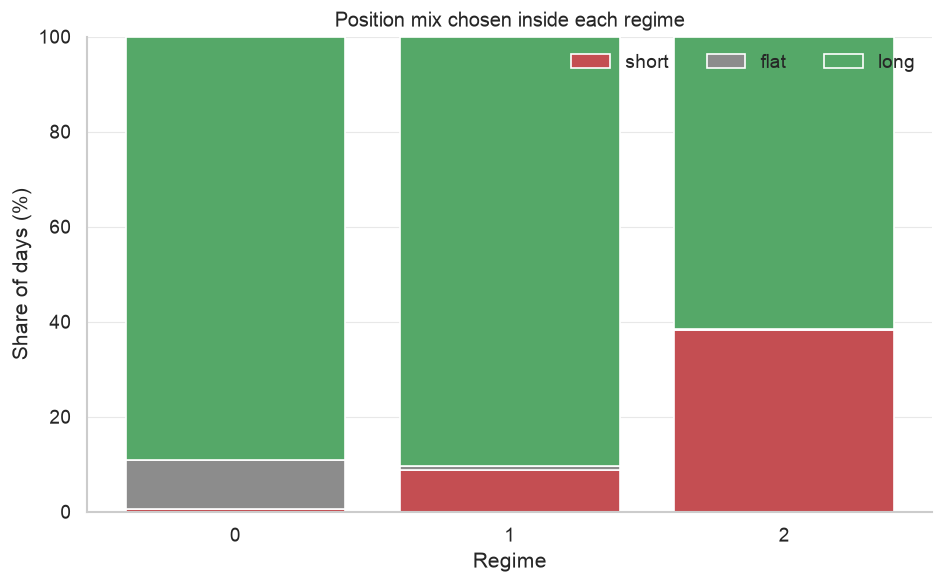

In [29]:
fig = plot_policy_by_regime(regime_map)
plt.show()
save_figure(fig, "policy_by_regime", FIG_DIR / "rl")

The action mix does shift across regimes, so the label is changing decisions rather than being ignored. It simply changes them for the worse on this data, which is the distinction between a feature the model uses and a feature that helps.

---
## 10. Final evaluation, walk-forward, and costs

### 10.1 Against the baselines

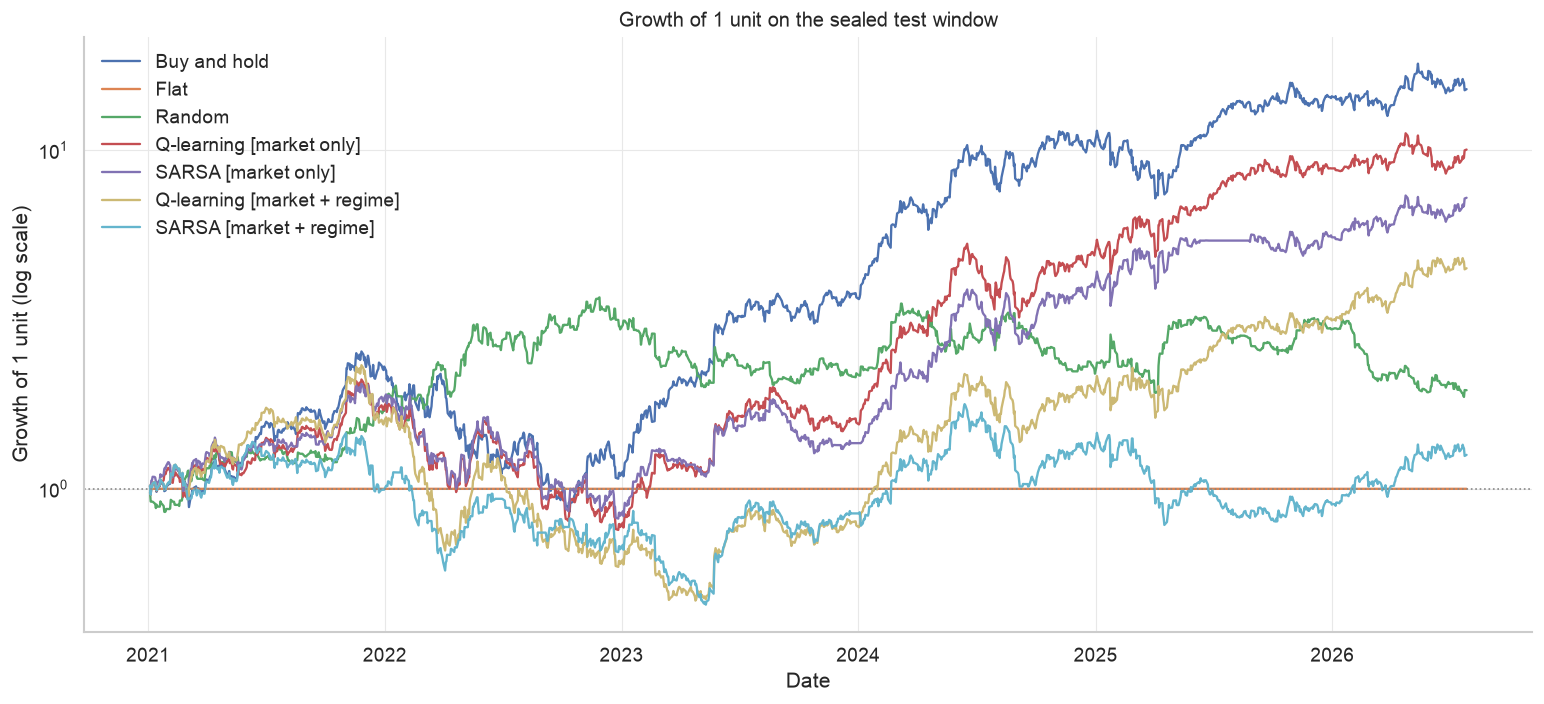

In [30]:
fig = plot_equity_curves(equity_curves(ledgers), "Growth of 1 unit on the sealed test window")
plt.show()
save_figure(fig, "equity_curves", FIG_DIR / "evaluation")

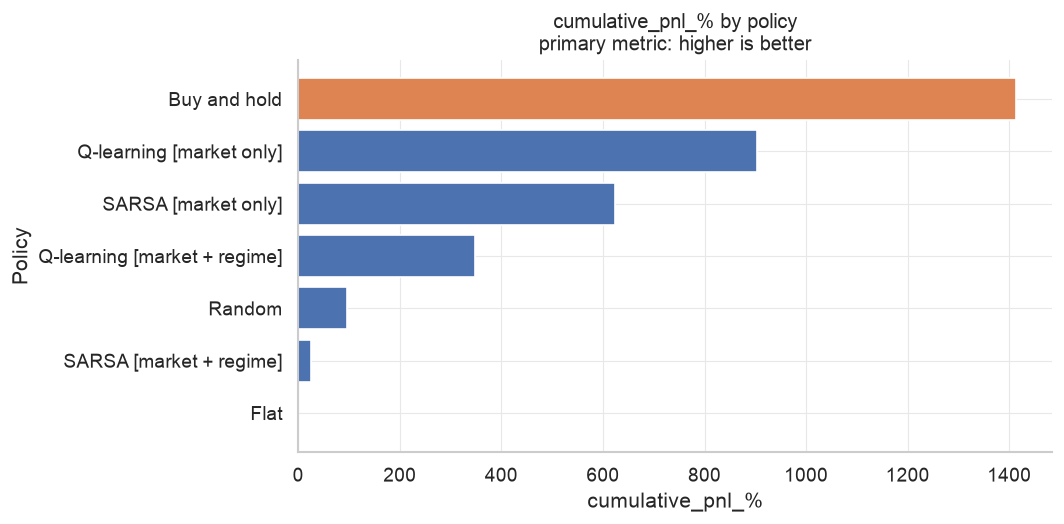

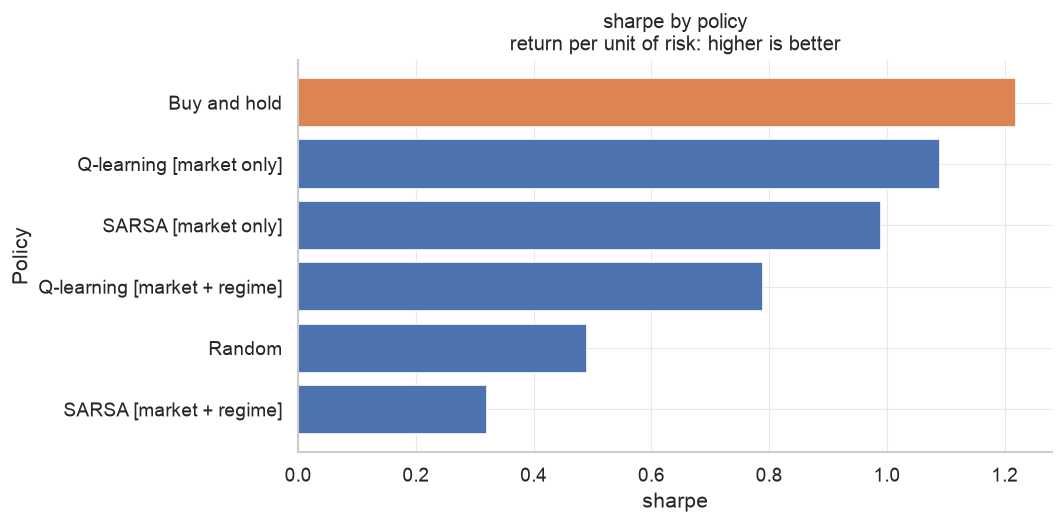

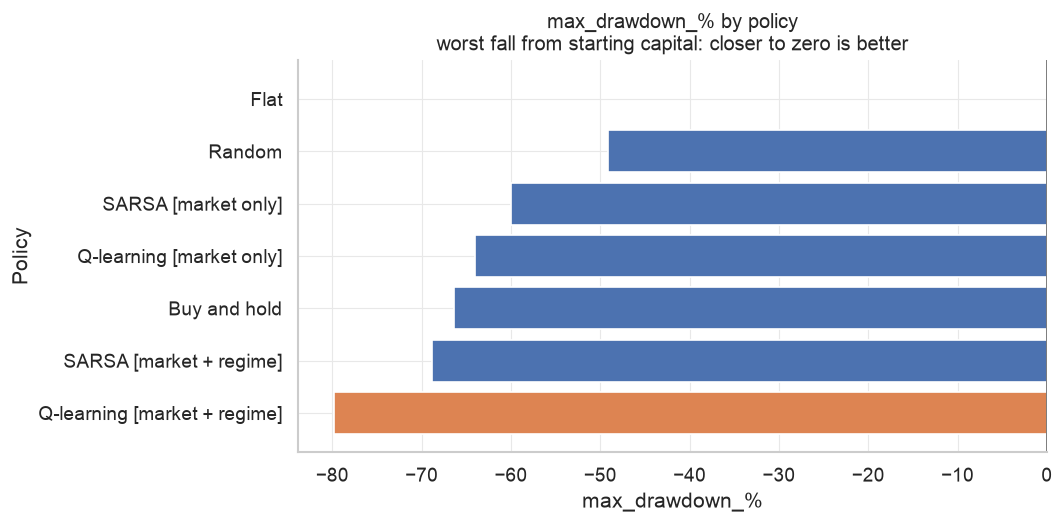

In [31]:
for metric, note in [("cumulative_pnl_%", "primary metric: higher is better"),
                     ("sharpe", "return per unit of risk: higher is better"),
                     ("max_drawdown_%", "worst fall from starting capital: closer to zero is better")]:
    fig = plot_metric_comparison(summary, metric, note)
    plt.show()
    save_figure(fig, f"comparison_{metric.strip('%_')}", FIG_DIR / "evaluation")

**No agent beats buy-and-hold.** The best of them, Q-learning on the market-only state, returns about +904% against buy-and-hold's +1414%, with a lower Sharpe. On a stock that rose roughly fifteen-fold over the test window with no profitable shorting opportunity, that is the expected outcome, and the earlier version of this notebook only appeared to tie because of the timing bug.

What the agents do achieve is beating random position-taking by a wide margin, and they do it while holding a position most of the time rather than churning. Random trades 221 units of turnover a year against the best agent's 123.

### 10.2 Was it one good year or a repeatable edge?

A single figure spanning 2021 to 2026 hides which regime produced it.

In [32]:
best_key = max((k for k in ledgers if "[" in k),
               key=lambda k: ledgers[k]["net_return"].sum())
print(f"Best agent: {best_key}\n")
walk_forward(ledgers[best_key])

Best agent: Q-learning [market only]



,days,return_%,sharpe,max_drawdown_%,turnover_per_year
year,,,,,
2021,252,74.90,1.48,-23.61,97.0
2022,251,-55.91,-1.08,-57.84,228.9
2023,250,103.40,1.75,-25.88,112.9
2024,252,220.90,2.49,-39.42,82.0
2025,250,75.50,1.43,-23.96,97.8
2026,141,13.67,0.80,-23.98,119.7


This is the most important table in the section, and it is not flattering.

The agent is strongly positive in 2021, 2023, 2024, and 2025, and then loses more than half its capital in 2022 with a Sharpe of about -1.1 and a drawdown near -58%. Its turnover more than doubles that year, which is the signature of a policy thrashing in conditions it does not recognise: 2022 is the one genuinely sustained bear market in the test window, and the training years contained nothing like it.

So the headline number is not a repeatable edge. It is four good years carrying one very bad one, and a desk that had deployed this in January 2022 would have shut it down before the good years arrived.

### 10.3 How much friction can it survive?

A flat 10 bps is a starting assumption, not a fact. This strategy trades enough that slippage or borrow costs on the short leg could change the conclusion rather than trim it.

In [33]:
best_cols = REGIME_STATE if "regime" in best_key else MARKET_STATE
cost_sensitivity(test, best_cols, agents[best_key].greedy_policy())

,cumulative_pnl_%,ann_return_%,sharpe,max_drawdown_%,turnover_per_year
cost_bps,,,,,
0.0,1887.50,71.54,1.34,-54.29,123.3
5.0,1312.97,61.29,1.21,-59.46,123.3
10.0,904.22,51.65,1.09,-64.05,123.3
20.0,406.78,34.04,0.84,-71.73,123.3
50.0,-35.34,-7.57,0.09,-86.30,123.3


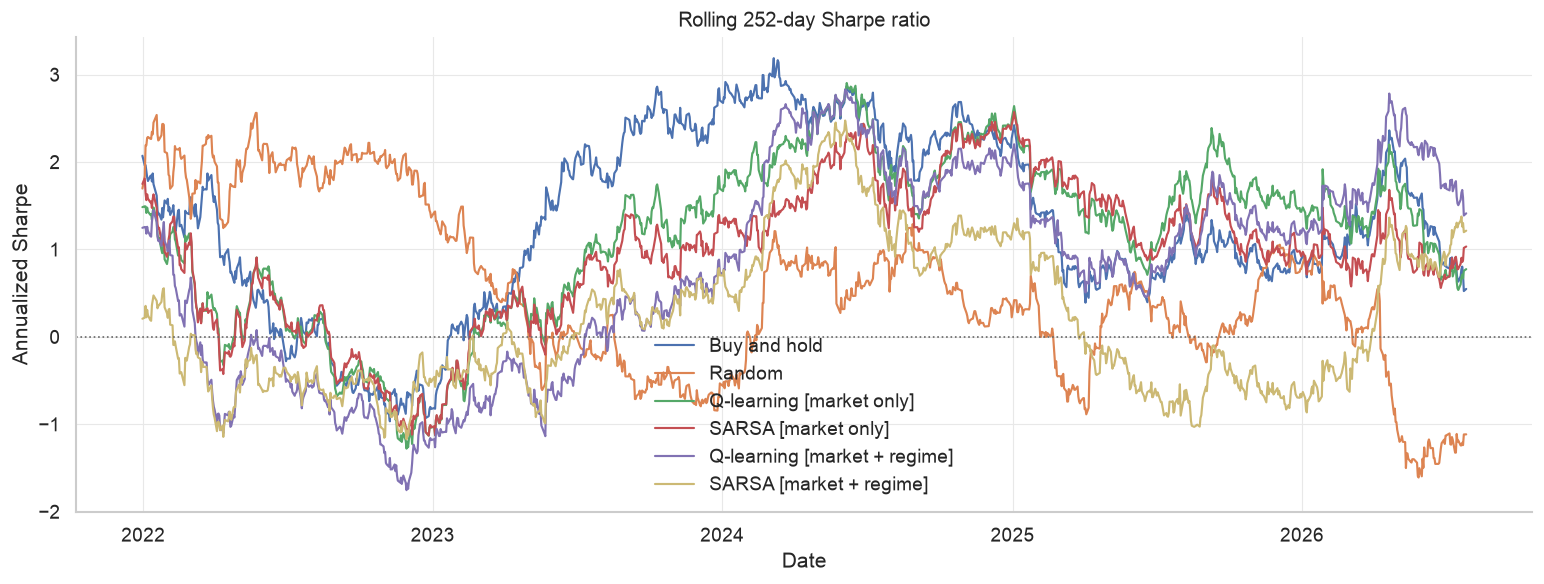

In [34]:
fig = plot_rolling_sharpe({k: v for k, v in ledgers.items() if k != "Flat"})
plt.show()
save_figure(fig, "rolling_sharpe", FIG_DIR / "evaluation")

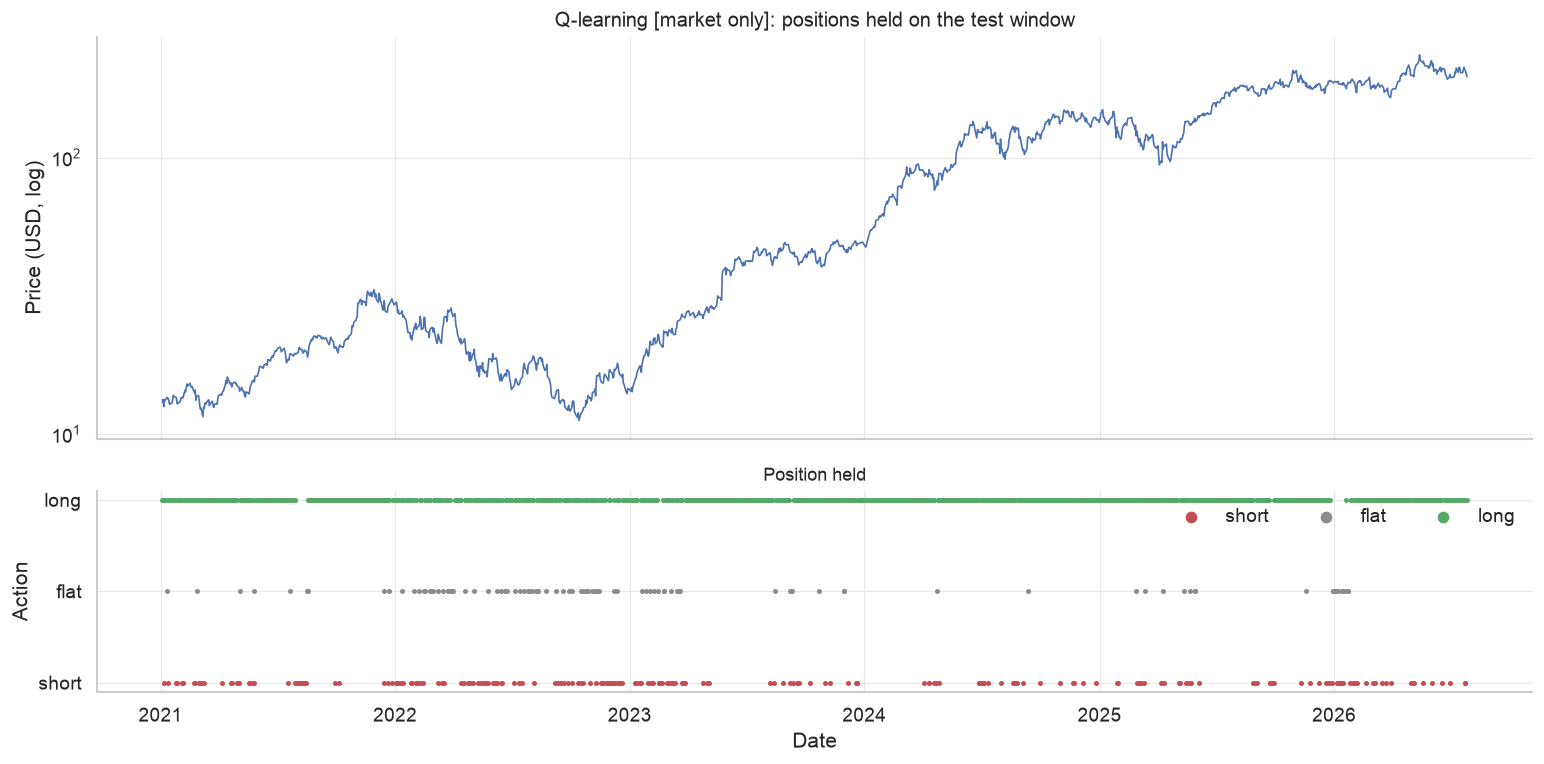

In [35]:
fig = plot_action_timeline(ledgers[best_key], test["close"],
                          f"{best_key}: positions held on the test window")
plt.show()
save_figure(fig, "action_timeline", FIG_DIR / "rl")

The cost curve is the practical answer to "would this work". Frictionless, the strategy roughly doubles the reported result. At the headline 10 bps it lands where Section 10.1 shows. By 20 bps it has given up more than half of that again, and somewhere before 50 bps it turns negative outright.

Since 50 bps is not an unreasonable all-in cost for a daily-rebalanced strategy that shorts, the honest reading is that the edge lives entirely inside the assumption that execution is cheap. Buy-and-hold, which trades twice, is almost indifferent to the same axis. That asymmetry matters more than the PnL gap.

### 10.4 Reading the results honestly

Three things are true at once, and the project is more useful for holding all three.

The **unsupervised half worked**. The regimes are stable, persistent, and genuinely informative about forward risk, verified on quantities the clustering never saw.

The **RL half did not beat the benchmark**. Correct timing and a fair comparison leave every agent behind buy-and-hold, and the best one owes its total to four good years around one disastrous one.

And the **regime label did not help the agent**, despite being informative, because tripling a tabular state space costs more in estimation error than the label repays. That is a genuine result about method rather than about markets, and it points somewhere specific: use function approximation, not a bigger table.

---
## 11. Conclusion, limitations, and recommendations

### Conclusion

The clustering found three regimes that hold up: stable under reseeding and bootstrap, persistent over weeks, and predictive of forward volatility and drawdown on data they were never fitted to. As a description of market state, they work.

The trading agent is a different story. Once the reward timing was corrected and the baseline was given the same features the regime was built from, no agent beat buy-and-hold, the best reached about +904% against +1414%, and adding the regime label actively hurt. Its apparent success in an earlier version came from a one-day timing shift and a comparison that fed the regime arm two extra features.

The one finding I would defend to a desk: **an informative feature is not the same as a useful state variable.** The regimes predict forward risk, and a tabular agent still cannot profit from them, because tripling the state space costs more than the information is worth.

### Limitations

- One stock, one bull market. Every dip recovered, which flatters anything long.
- The walk-forward shows 2022 alone erasing more than half of capital. One bad regime undoes several good years.
- The edge disappears somewhere between 20 and 50 bps of cost, which is inside the plausible range for a daily strategy that shorts.
- The state is coarse, two bins per feature, so the agent cannot see whether volatility is rising or falling.
- Positions are fixed at -1, 0, +1, so it cannot size by conviction or express "long but small" in a stressed regime.
- In-sample results remain far above test results; the table memorizes the tape.

### Recommendations

- Replace the table with function approximation. That is the direct fix for the ablation result: a model that shares strength across similar states could use the regime information the table cannot afford.
- Use the regimes for **risk sizing** rather than direction, since forward drawdown is what they predict best.
- Run the same pipeline on a stock that never recovered, which is the real test of the survivorship problem.
- Model costs properly, including slippage and borrow, before treating any of this as tradable.